## Outlier Detection using IQR

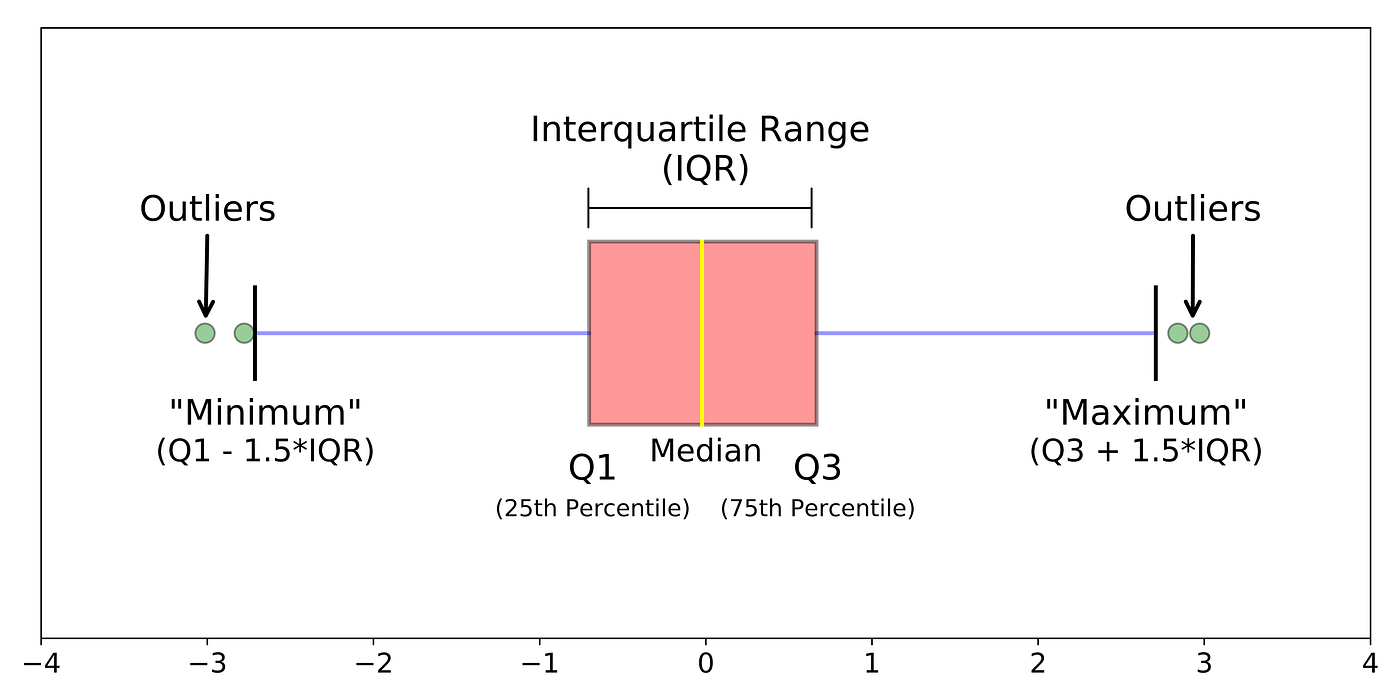

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
df=pd.read_csv('dataset/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


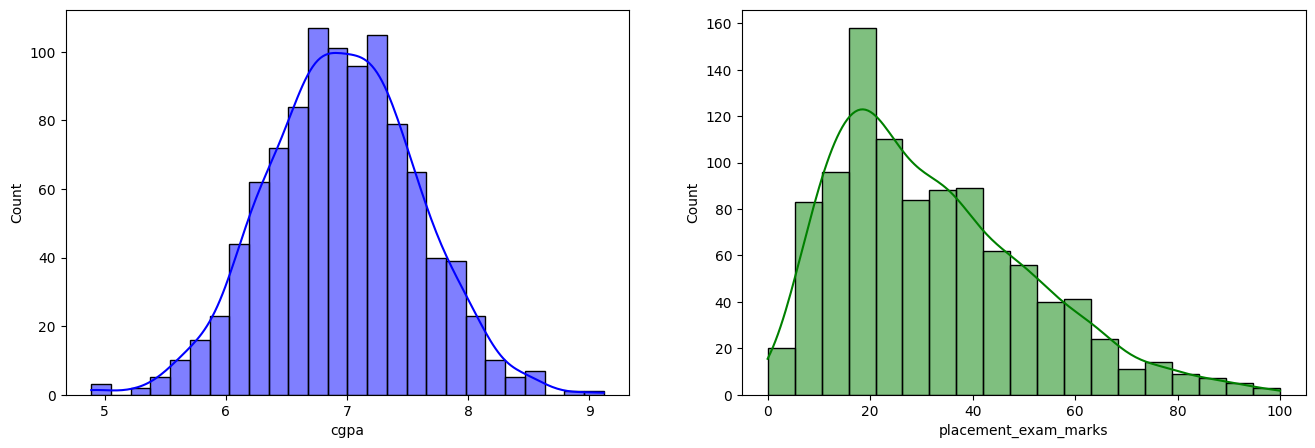

In [3]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df,x='cgpa',fill=True,label='CGPA',color='blue',kde=True)

plt.subplot(1,2,2)
sns.histplot(data=df,x='placement_exam_marks',fill=True,label='Placement Exam Marks',color='green',kde=True)
plt.show()

In [10]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [11]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [12]:
print('Mean value of cgpa:',df['cgpa'].mean())
print('Std value of cgpa:',df['cgpa'].std())
print('Min value of cgpa:',df['cgpa'].min())
print('Max value of cgpa:',df['cgpa'].max())

Mean value of cgpa: 6.96124
Std value of cgpa: 0.6158978751323894
Min value of cgpa: 4.89
Max value of cgpa: 9.12


In [13]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

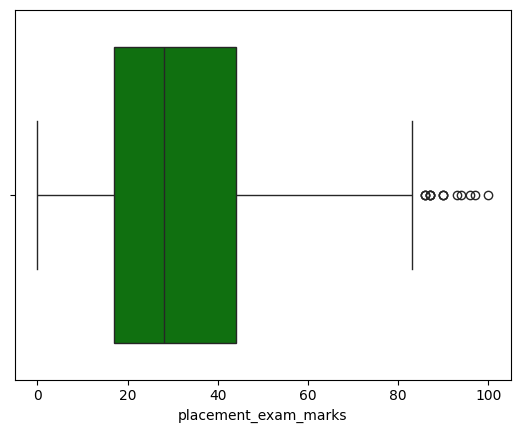

In [14]:
sns.boxplot(data=df,x='placement_exam_marks',color='green')

In [15]:
# finding the IQR
Q1=df['placement_exam_marks'].quantile(0.25)
Q3=df['placement_exam_marks'].quantile(0.75)

In [16]:
Q1

np.float64(17.0)

In [17]:
Q3

np.float64(44.0)

In [18]:
iqr=Q3-Q1
iqr

np.float64(27.0)

In [19]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr

In [20]:
print('Upper limit:',upper_limit)
print('Lower limit:',lower_limit)

Upper limit: 84.5
Lower limit: -23.5


### Finding Outliers

In [25]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [26]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


In [29]:
## Trimming

new_df=df[df['placement_exam_marks']<upper_limit]

In [30]:
new_df.shape

(985, 3)

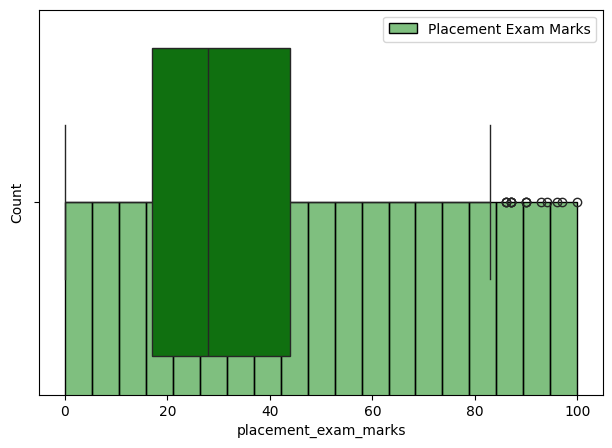

In [33]:
plt.figure(figsize=(16,5))
# plt.subplot(1,2,1)
# sns.histplot(data=df,x='cgpa',fill=True,label='CGPA',color='blue',kde=True)
# sns.boxplot(data=df,x='cgpa',color='blue')

plt.subplot(1,2,2)
sns.histplot(data=df,x='placement_exam_marks',fill=True,label='Placement Exam Marks',color='green',kde=True)
plt.subplot(1,2,2)
sns.boxplot(data=df,x='placement_exam_marks',color='green')
plt.show()

## Capping

In [34]:
new_df_cap=df.copy()
new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']

    )
)

In [35]:
np.where(new_df_cap['placement_exam_marks']>upper_limit,upper_limit,new_df_cap['placement_exam_marks'])

array([26. , 38. , 40. ,  8. , 17. , 23. , 11. , 39. , 38. , 84.5, 16. ,
        7. , 16. , 26. , 43. , 21. , 19. , 22. , 27. , 29. , 47. , 33. ,
       54. , 11. , 11. , 58. ,  8. , 46. , 19. , 15. , 16. , 44. , 11. ,
       27. ,  9. , 12. , 16. ,  9. , 20. , 17. , 84.5, 38. , 71. , 63. ,
       55. , 10. , 15. , 46. , 42. , 28. , 18. , 28. , 27. , 33. , 36. ,
       15. , 15. , 24. , 43. , 32. , 31. , 84.5, 22. , 26. , 52. , 28. ,
       31. , 18. , 30. , 44. , 17. , 20. , 19. , 12. ,  3. , 56. , 12. ,
       28. , 12. , 19. , 46. , 44. , 12. , 20. , 35. , 28. , 22. , 19. ,
       39. , 17. , 15. ,  6. , 63. , 30. , 21. , 35. , 28. , 52. , 76. ,
       23. , 46. , 26. , 22. , 18. , 47. , 12. , 22. ,  9. , 10. , 21. ,
       31. , 33. , 15. , 10. , 77. , 37. , 21. ,  0. , 54. , 39. , 46. ,
       27. , 51. , 52. , 30. , 55. , 37. , 23. , 25. , 39. , 53. , 19. ,
       18. , 64. , 84.5, 47. , 15. , 53. ,  8. ,  5. , 22. , 18. , 41. ,
       33. , 17. , 28. , 22. , 11. , 49. , 58. , 22

In [37]:
new_df_cap.shape

(1000, 3)